<a href="https://colab.research.google.com/github/Harsha-Verma/Cab-Fare-prediction-analysis/blob/main/Fare_prediction_Project_Harsha_Verma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚕**Predict the fare amount of future rides using regression analysis** **bold text**

🎯**Objective**

The objective of this module is to explore, clean, and prepare ride fare data for building a regression model that predicts fare amount for future rides.



















### **Importing the Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Loading the Data set**

In [2]:
url="https://raw.githubusercontent.com/Harsha-Verma/Cab-Fare-prediction-analysis/refs/heads/main/Uber_Dataset.csv"
df_raw = pd.read_csv(url)
df=df_raw.copy()

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


### **Basic Date Exploration**

Initial exploration helps understand fare distribution, feature ranges, and potential data quality issues before modeling.

In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


### **Handling Missing Values**

In [5]:
# Checking the presence of null values

df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [6]:
# Treating null values

null_cols=df.select_dtypes(include=np.number).columns
for cols in null_cols: df[cols]=df[cols].fillna(df[cols].median())

df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [7]:
# Dropping the columns not required

df.drop(columns=['Unnamed: 0', 'key'], inplace=True)

In [8]:
# Extracting the values greater than 0 only.

df = df[df['fare_amount'] > 0]

In [9]:
# again checking the shape after removing uneccessary column

df.shape

(199978, 7)

### **Feature Engineering**

In [10]:
# Converting the data type of pickup_datetime column to datetime

df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [11]:
# Rechecking the data type fo columns

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199978 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        199978 non-null  float64            
 1   pickup_datetime    199978 non-null  datetime64[ns, UTC]
 2   pickup_longitude   199978 non-null  float64            
 3   pickup_latitude    199978 non-null  float64            
 4   dropoff_longitude  199978 non-null  float64            
 5   dropoff_latitude   199978 non-null  float64            
 6   passenger_count    199978 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1)
memory usage: 12.2 MB


In [12]:
# Extracting the Time Features

df['pickup_hour']=df['pickup_datetime'].dt.hour
df['pickup_day']= df['pickup_datetime'].dt.day
df['pickup_month']= df['pickup_datetime'].dt.month
df['pickup_year']=df['pickup_datetime'].dt.year
df['pickup_dayofweek']=df['pickup_datetime'].dt.dayofweek

In [13]:
# Extracting the columns

df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_year',
       'pickup_dayofweek'],
      dtype='object')

In [14]:
# Removing invalid coordinates

df=df[(df['pickup_latitude'].between(-90,90))&
(df['dropoff_latitude'].between(-90,90))&
(df['pickup_longitude'].between(-180,180))&
(df['dropoff_longitude'].between(-180,180))]

*We have validate the coordinates (Latitude & Longitude values) because invalid coordinates can lead to incorrect distance calculations and introduce extreme outliers.This can negatively impact the regression model performance.To ensure data quality such rows were removed.*

*Latitude must lie between -90 and 90 degrees, and longitude between -180 and 180 degrees,as these are the valid geographic boundaries of the Earth.*



In [15]:
# Haversine Distance calculation

from math import radians, sin, cos, asin, sqrt

def haversine(lat_1,lon_1,lat_2,lon_2):
  lat_1,lon_1,lat_2,lon_2 = map(radians,[lat_1,lon_1,lat_2,lon_2])
  lat_diff = lat_2 - lat_1
  lon_diff = lon_2 - lon_1
  R = 6371
  a = sin(lat_diff/2)**2 + cos(lat_1)*cos(lat_2)*sin(lon_diff/2)**2
  c = 2*asin(sqrt(a))
  return R * c

In [16]:
# Calculating the Distance

df['distance_km'] = df.apply(
    lambda row: haversine(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ),
    axis=1
)

In [17]:
#Removing extreme values from distance_km column

df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 100)]

In [18]:
# Statistical description of calculated distance_km column

df['distance_km'].describe()

,distance_km
count,192706.000000
mean,3.381751
std,3.730294
min,0.100227
25%,1.294222
50%,2.192039
75%,3.956178
max,99.162509


*After computing trip distance using the Haversine formula, zero-distance rides and unrealistically long trips were removed. The resulting distance distribution aligns with real-world taxi trip behavior, with a mean distance of 3.38 km and median of 2.19 km. Distance was retained as a continuous variable to preserve predictive power for regression modeling.*

### **Feature Visualization**

**Fare Vs Distance**

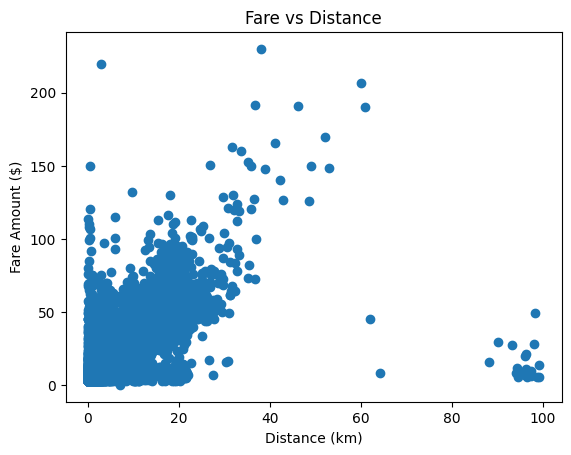

In [19]:
# Visualizing the relationship between fare and distance

plt.figure()
plt.scatter(df['distance_km'], df['fare_amount'])
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Distance")
plt.show()

**Fare Distribution**

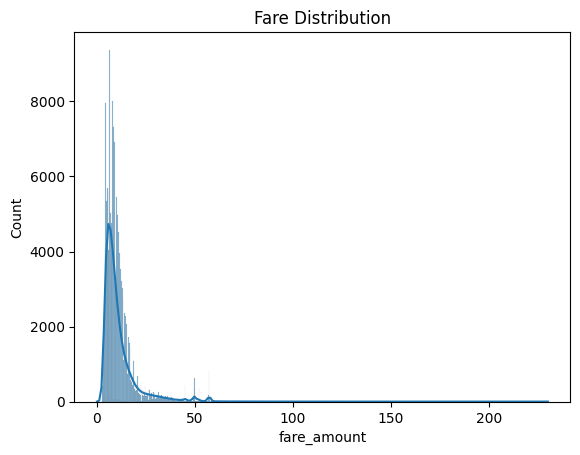

In [20]:
# Visualizing the distribution of fare

plt.figure()
sns.histplot(df['fare_amount'], kde=True)
plt.title("Fare Distribution")
plt.show()

**Distance Distribution**

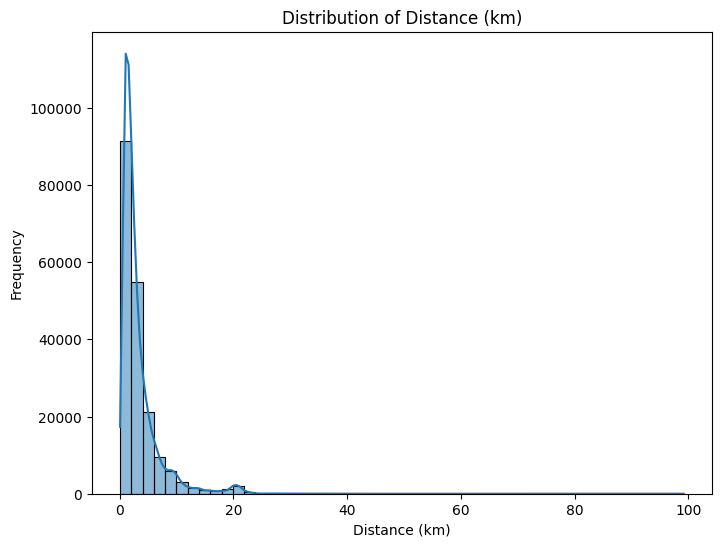

In [21]:
# Visualizing the distribution of distance

plt.figure(figsize=(8, 6))
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title('Distribution of Distance (km)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

### **Identifying and Removing Outliers**

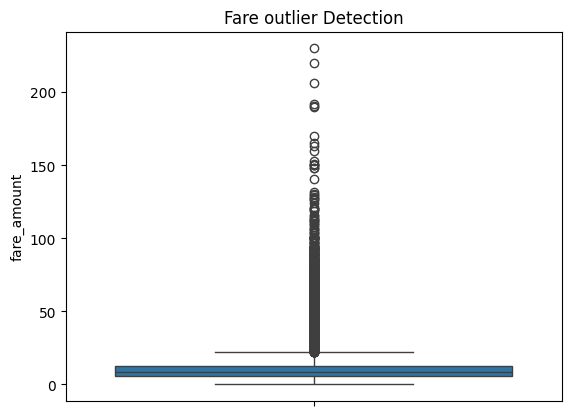

In [22]:
# Identifying Outliers

plt.figure()
sns.boxplot(df['fare_amount'])
plt.title("Fare outlier Detection")
plt.show()

In [23]:
# Removing outliers

fare_low  = df['fare_amount'].quantile(0.01)
fare_high = df['fare_amount'].quantile(0.99)

df_clean = df[
    (df['fare_amount'] >= fare_low) &
    (df['fare_amount'] <= fare_high)
]

In [24]:
# Here we are creating a copy of cleaned dataset

df_clean = df.copy()

In [25]:
# Checking the copied dataset

df_clean

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,distance_km
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5,2015,3,1.683323
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7,2009,4,2.457590
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8,2009,0,5.036377
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6,2009,4,1.661683
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8,2014,3,4.475450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,10,28,10,2012,6,0.112210
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,1,14,3,2014,4,1.875050
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,29,6,2009,0,12.850319
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695416,1,14,20,5,2015,2,3.539715


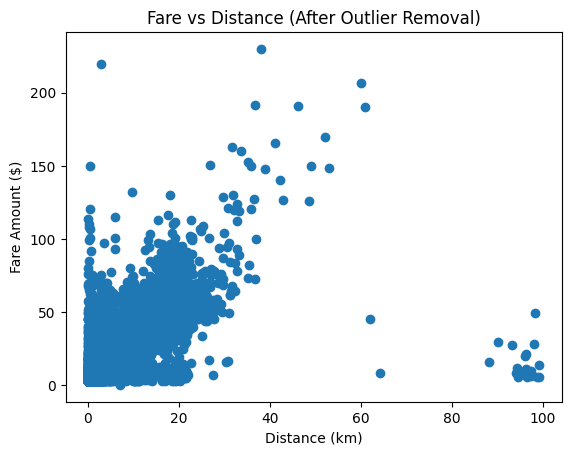

In [26]:
# Visualizing the relationship between distance and fare_amount after removal of outliers

plt.scatter(df_clean['distance_km'], df_clean['fare_amount'])
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare vs Distance (After Outlier Removal)')
plt.show()

In [27]:
# Dropping the unneccesary columns which are created in feature engineering

df_clean = df_clean.drop(
    columns=[
        'pickup_datetime',
        'pickup_latitude',
        'pickup_longitude',
        'dropoff_latitude',
        'dropoff_longitude'
    ],
    errors='ignore'
)

In [28]:
# Rechecking the dataset

df_clean.head()
df_clean.describe()

,fare_amount,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,distance_km
count,192706.000000,192706.000000,192706.000000,192706.000000,192706.000000,192706.000000,192706.000000,192706.000000
mean,11.318884,1.684914,13.493228,15.702319,6.280785,2011.746894,3.048966,3.381751
std,9.511896,1.307840,6.513911,8.687590,3.440428,1.859570,1.946547,3.730294
min,0.010000,0.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.100227
25%,6.000000,1.000000,9.000000,8.000000,3.000000,2010.000000,1.000000,1.294222
50%,8.500000,1.000000,14.000000,16.000000,6.000000,2012.000000,3.000000,2.192039
75%,12.500000,2.000000,19.000000,23.000000,9.000000,2013.000000,5.000000,3.956178
max,230.000000,6.000000,23.000000,31.000000,12.000000,2015.000000,6.000000,99.162509


### **Correlation Analysis**

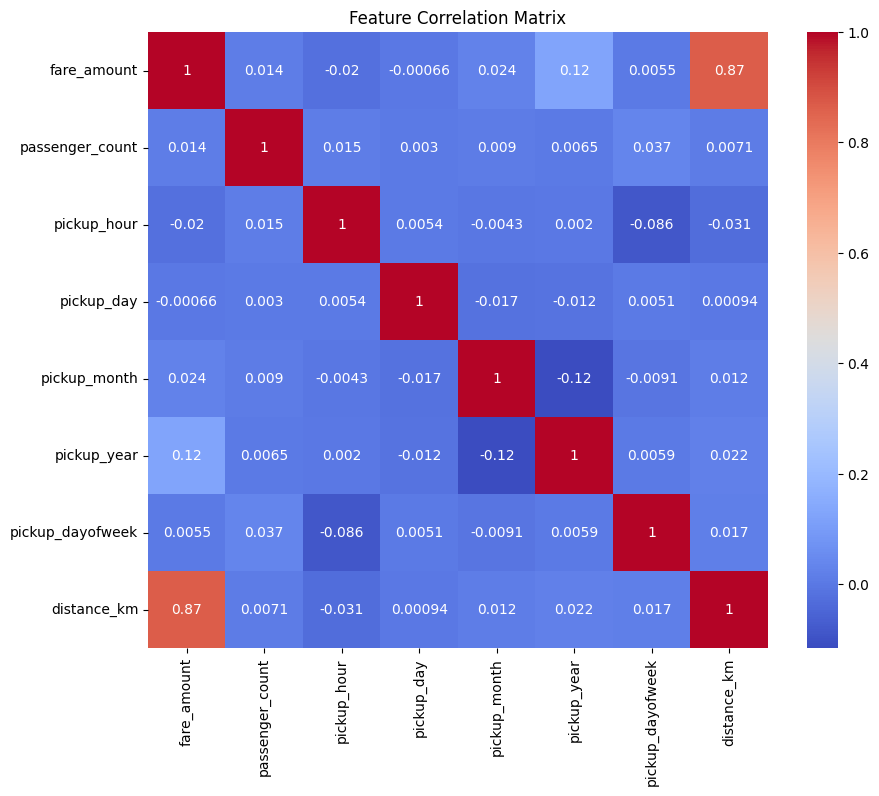

In [29]:
# Identifying how features are correlated to each other

df_num = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Correlation analysis shows that trip distance has a strong positive relationship
with fare amount, making it the most influential feature for regression modeling.Passenger count shows weak correlation and may have limited predictive power.

### **Feature Scaling/Normalization**

**X and y for Base Model**


In [30]:
X = df_clean[['distance_km']]
y = df_clean['fare_amount']

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Splitting the data into train & test data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling after the data is splitted
scaler = StandardScaler()

# Reshape X_train and X_test to 2D arrays before scaling
X_train_scaled = scaler.fit_transform(X_train.values.reshape(-1, 1))
X_test_scaled = scaler.transform(X_test.values.reshape(-1, 1))

Feature scaling was performed using StandardScaler to normalize numerical features.
Standardization ensures that features with larger magnitudes do not dominate
the regression model and improves numerical stability.

# 📊 **Regression Modelling**

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Inorder to check which model performs better we are running various algorithms to generate Base Model.

### **Linear Regression**

In [33]:
lr= LinearRegression()
lr.fit(X_train,y_train)

print("Intercept",lr.intercept_)
print("Coefficient",lr.coef_)

y_pred_lr=lr.predict(X_test)

r2_score(y_test,y_pred_lr)
mae_lr = mean_absolute_error(y_test,y_pred_lr)
mse_lr = mean_squared_error(y_test,y_pred_lr)

print("Linear Regression Performance:")
print("R2",r2_score(y_test,y_pred_lr))
print("MAE",mae_lr)
print("MSE",mse_lr)

compare= pd.DataFrame({"Actual Label":y_test,"Predicted Label":y_pred_lr})
compare.reset_index().drop(["index"],axis=1)


Intercept 3.881708924926291
Coefficient [2.19862321]
Linear Regression Performance:
R2 0.7734655599382328
MAE 2.3236207194576606
MSE 20.576369835040612


,Actual Label,Predicted Label
0,6.5,7.074897
1,13.5,5.602971
2,6.5,7.111037
3,8.5,8.441664
4,11.0,11.552422
...,...,...
38537,12.0,9.955692
38538,10.0,9.742806
38539,5.0,7.222496
38540,10.0,10.686480


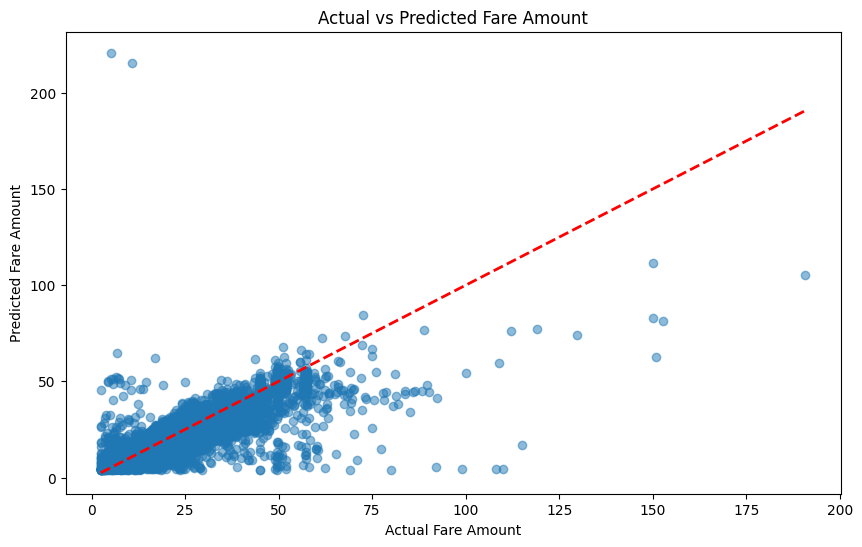

In [34]:
# Visualize Predicted vs Actual
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare Amount')
plt.ylabel('Predicted Fare Amount')
plt.title('Actual vs Predicted Fare Amount')
plt.show()

### **Decision Tree Regressor**

In [35]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

r2_score(y_test,y_pred_dt)
mae_dt = mean_absolute_error(y_test,y_pred_dt)
mse_dt = mean_squared_error(y_test,y_pred_dt)


print("Decision Tree Performance:")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mae_dt)
print("MSE:", mse_dt)



Decision Tree Performance:
R2 Score: 0.6281736458131151
MAE: 3.177544496912459
MSE: 33.773392584712774


### **Random Forest Regressor**

In [36]:
rf=RandomForestRegressor (random_state=42)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

r2_score(y_test,y_pred_rf)
mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)


print("Decision Tree Performance:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mae_rf)
print("MSE:", mse_rf)


Decision Tree Performance:
R2 Score: 0.7259142569244159
MAE: 2.751528901643476
MSE: 24.895506460286644


## **Gradient Boosting Regressor**

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

gbr=GradientBoostingRegressor(random_state=42)
gbr.fit(X_train,y_train)

y_pred_gbr=gbr.predict(X_test)

r2_score(y_test,y_pred_gbr)
mae_gbr = mean_absolute_error(y_test,y_pred_gbr)
mse_gbr = mean_squared_error(y_test,y_pred_gbr)


print("Gradient Boosting Performance:")
print("R2 Score:", r2_score(y_test, y_pred_gbr))
print("MSE:", mse_gbr)
print("MAE:", mae_gbr)



Gradient Boosting Performance:
R2 Score: 0.8079907216470086
MSE: 17.440411807022215
MAE: 2.2478259685280206


### **Evaluating Model Performance**

**Comparing Models**

We have compared models generated by running various algorithms for base model considering:

 X=distance_km (only feature)

 y=fare_amount

In [38]:
Model_Comparison = pd.DataFrame({
    'Model':['Linear Regression','Decision Tree','Random Forest','Gradient Boosting'],
    'R2 score':[r2_score(y_test,y_pred_lr),r2_score(y_test,y_pred_dt),r2_score(y_test,y_pred_rf),r2_score(y_test, y_pred_gbr)],
    'MAE':[mae_lr,mae_dt,mae_rf,mae_gbr],
    'MSE':[mse_lr,mse_dt,mse_rf,mse_gbr]

})

Model_Comparison

,Model,R2 score,MAE,MSE
0,Linear Regression,0.773466,2.323621,20.576370
1,Decision Tree,0.628174,3.177544,33.773393
2,Random Forest,0.725914,2.751529,24.895506
3,Gradient Boosting,0.807991,2.247826,17.440412


As we have evaluated our base models and through the model_comparison we observed Gradient Boosting Regressor is giving better performance over Linear regression & Randome Forest.Hence it is the best model with following measures:-

1.   Highest R2 (with variance approx 80%)
2.   Lowest MAE (approx 2.24 dollars)

Whereas Decision Tree perfoms poorly.

**Comparing Train Vs Test R2 score-for Gradient Boosting Regressor**

In [39]:
gbr.fit(X_train, y_train)

# Predict on train and test
y_train_pred = gbr.predict(X_train)
y_test_pred = gbr.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

Train R2 : 0.8179948127685474
Test R2  : 0.8079907216470086


Since two scores are very close. The model generalizes well. There is no underfitting and overfitting. So Hypertunning would not impact the performance much with a huge jump. Thus Hyper-Tuning not required.

### **Feature Importance Interpretation**

**Model-1 (Distance Only: Baseline)**

In [40]:
X1 = df_clean[['distance_km']]
y = df_clean['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Test R2 (distance only):", r2_score(y_test, y_pred))

Test R2 (distance only): 0.8079907216470086


**Model-2 (Distance + Passenger Count)**

In [41]:
X2 = df_clean[['distance_km', 'passenger_count']]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print("Test R2 (+ passenger_count):", r2_score(y_test, y_pred))

Test R2 (+ passenger_count): 0.8081418545245955


**Model-3 (Distance + Passenger Count + Pickup Hour)**

In [42]:
X3 = df_clean[['distance_km', 'passenger_count', 'pickup_hour']]

X_train, X_test, y_train, y_test = train_test_split(
    X3, y, test_size=0.2, random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print("Test R2 (+ pickup_hour):", r2_score(y_test, y_pred))

Test R2 (+ pickup_hour): 0.8158716079387862


**Model-4 (Distance + Passenger Count + Pickup Hour + Pickup Year)**

In [43]:
X4 = df_clean[['distance_km', 'passenger_count', 'pickup_hour', 'pickup_year']]

X_train, X_test, y_train, y_test = train_test_split(
    X4, y, test_size=0.2, random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print("Test R2 (all features):", r2_score(y_test, y_pred))

Test R2 (all features): 0.8349586652514461


**Feature Importance-Final Model**

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X4.columns,
    'Importance': gbr.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,distance_km,0.966458
3,pickup_year,0.025074
2,pickup_hour,0.008255
1,passenger_count,0.000214


## ✍**Interpret Feature Importance**

The Gradient Boosting Regressor was used to analyze the importance of features
in predicting the fare amount. Feature importance scores indicate how much
each feature contributes to the model’s predictions.

---

### **Feature Importance Results**

- **distance_km**: 0.966  
- **pickup_year**: 0.025  
- **pickup_hour**: 0.008  
- **passenger_count**: 0.0002  

---

### **Interpretation**

***Distance (distance_km)*** is the most significant factor influencing fare amount.
It contributes over 96% of the model’s predictive power, indicating that fare
pricing is primarily distance-based. This aligns with real-world ride-sharing
pricing logic, where longer trips result in higher fares.

***Pickup year*** has a small but meaningful impact on fare prediction. This feature
captures long-term changes such as inflation, fuel price variation, and updates
in pricing policies over time.

***Pickup hour*** shows limited influence on fare amount. This suggests that
time-of-day effects such as surge pricing are either weak or not consistently
captured in the dataset.

***Passenger count*** has negligible importance, indicating that the number of
passengers does not significantly affect fare calculation.

---

### ✅**Conclusion**

The analysis shows that distance is the dominant driver of fare amount.
Temporal features provide minor improvements, while passenger count does not
meaningfully contribute to prediction accuracy.

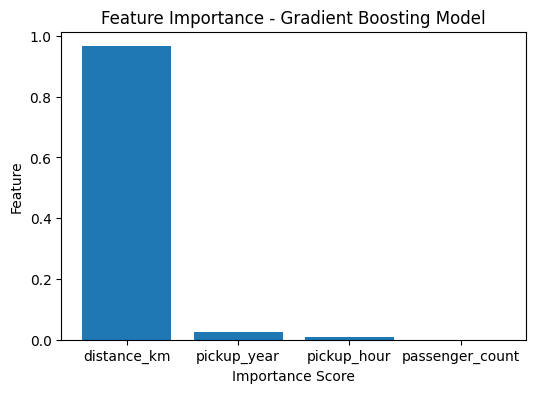

In [45]:
# Visualizing Feature Importance

plt.figure(figsize=(6, 4))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance - Gradient Boosting Model")
plt.show()

After training our model through Gradient Boosting Regressor we have found the the feature importance scores:

where we found Distance as the most important feature acting as the dominant predictor for calculating the fare amount.

**Predicting fare amount on New Data**

In [46]:
# Creating New Ride data to predict fare for one new ride

new_ride = pd.DataFrame({
    'distance_km': [6.8],
    'passenger_count': [2],
    'pickup_hour': [18],
    'pickup_year': [2015]
})


# Predict fare
predicted_fare = gbr.predict(new_ride)

print("Predicted Fare Amount:", predicted_fare[0])

Predicted Fare Amount: 22.098532436856438


### 🔍**Making Predictions on New Ride Data**

After training and validating the Gradient Boosting Regression model, the model
was used to predict the fare amount for a new ride.

---

**New Ride Details**
The following features were provided to the model:

- Distance (km): 6.8  
- Passenger Count: 2  
- Pickup Hour: 18  
- Pickup Year: 2015  

---

**Prediction Result**

The model predicted a fare amount of: **$22.09 (approximately)**

---

**Interpretation**

The predicted fare reflects the strong influence of distance on pricing, as
identified in the feature importance analysis. The pickup hour and year provide
minor adjustments to the final fare, while passenger count has minimal impact.

---

**Potential Use Cases**

- *Real-time Fare Estimation:*  
  Ride-sharing platforms can use this model to provide fare estimates to users
  before confirming a ride.

- *Dynamic Pricing Analysis:*  
  The model can help analyze how fare amounts vary with distance and time-based
  factors.

- *Operational Planning:*
  Predicted fares can assist companies in forecasting revenue and planning
  driver incentives.

- *Customer Transparency:*  
  Accurate fare predictions improve user trust and satisfaction by reducing
  pricing uncertainty.

---

✅**Business Value**

By leveraging machine learning-based fare prediction, the company can optimize
pricing strategies, enhance customer experience, and make data-driven decisions
to improve overall service efficiency.

## 📌**Recommendations**

Based on the Gradient Boosting Regression model and feature importance analysis, the following recommendations are proposed.

---

### 1. Distance-Based Pricing Strategy
- **Insight:** Distance (distance_km) is the most influential feature, contributing ~96% to fare prediction.
- **Recommendation:** Distance should remain the primary factor in fare calculation.Granular distance slabs should be used for more accurate and transparent pricing.
- **Business Impact:** Improves pricing accuracy and transparency for predicted fare.

---

### 2. Peak Hour Pricing Optimization
- **Insight:** Pickup hour shows a moderate impact on fare amount.
- **Recommendation:** Apply surge pricing during peak demand hours.
- **Business Impact:** Better demand-supply balance and reduced ride cancellations.This improves platform reliability during peak hours.

---

### 3. Time-Based Driver Incentives
- **Insight:** Time-related features influence fare more than passenger-related features.
- **Recommendation:** Introduce driver incentives during high-demand time windows.
- **Business Impact:** This Improves ride availability,improves wait times for customers and enhance driver availability & retention.

---

### 4. Passenger Count Usage
- **Insight:** Passenger count has minimal impact on fare prediction.
- **Recommendation:** Use passenger count mainly for vehicle allocation, not for pricing.
- **Business Impact:** This leads to fair pricing,improved customer experience, improved vehicle utilization efficiency.

---

### 5. Operational Efficiency over Historical Factors
- **Insight:** pickup_year has limited influence compared to distance and time.
- **Recommendation:** Focus more on real-time data such as traffic conditions, demand, and distance rather than relying on historical year based adjustment.
- **Business Impact:** This keeps the pricing model adaptable and future-ready enabling faster response to market changes.

---

### ✅ **Conclusion**
The model indicates that **distance and time** are the key drivers of fare prediction. Aligning pricing strategies and operational decisions with these insights can enhance revenue efficiency and customer satisfaction.